## 📦 Step 1: Load the Dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🧹 Step 2: Data Preprocessing

In [2]:
# Drop columns not useful for logistic regression
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

# Handle missing values
df['Age'].fillna(df['Age'].median())
df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convert categorical variables to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Drop rows with remaining nulls (if any)
df = df.dropna()

# Feature matrix and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']


## 🔀 Step 3: Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 🤖 Step 4: Train Logistic Regression Model

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


LogisticRegression(max_iter=200)

## 📈 Step 5: Evaluate the Model

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7972027972027972
Confusion Matrix:
 [[73  7]
 [22 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.83        80
           1       0.85      0.65      0.74        63

    accuracy                           0.80       143
   macro avg       0.81      0.78      0.79       143
weighted avg       0.81      0.80      0.79       143



## 📊 Step 6: Feature Importance (Coefficients)

In [6]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)


    Feature  Coefficient
1       Sex     2.561794
0    Pclass    -1.317183
3     SibSp    -0.334429
6  Embarked     0.070976
2       Age    -0.037609
4     Parch     0.005062
5      Fare    -0.000348


## 🧠 Bonus: Predicting for New Data

In [7]:
new_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 0,
    'Age': 25,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked': 0
}])

prediction = model.predict(new_passenger)
print("Survived:" if prediction[0] == 1 else "Did not survive.")


Did not survive.


# 📊 Titanic Dataset Visual EDA

/tmp/ipykernel_1125/3916949795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


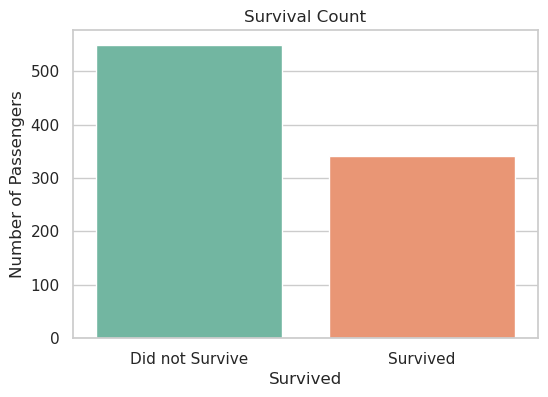

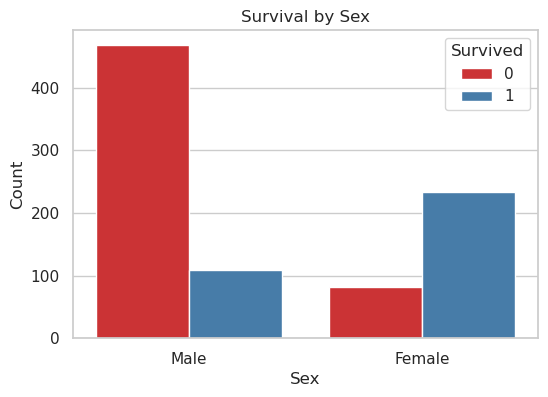

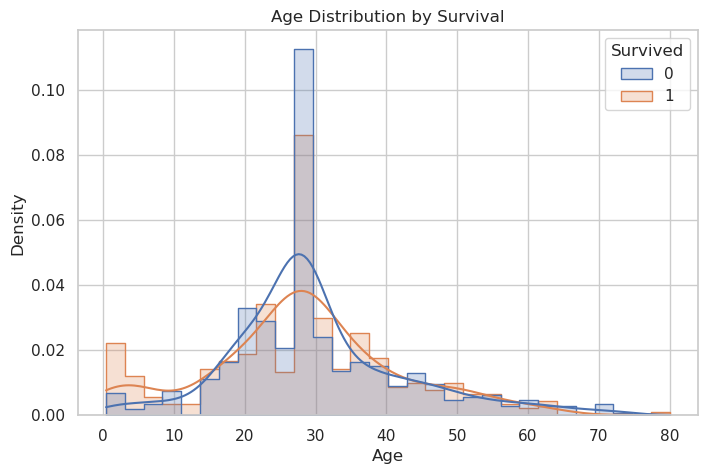

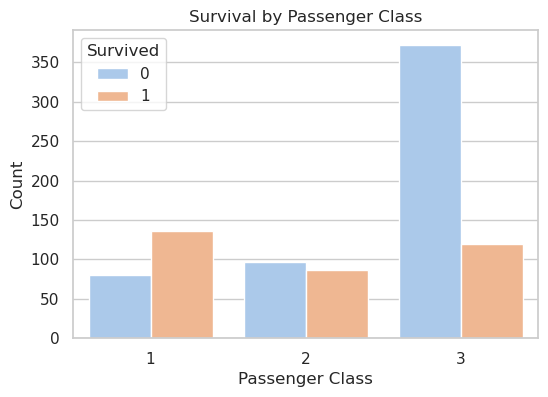

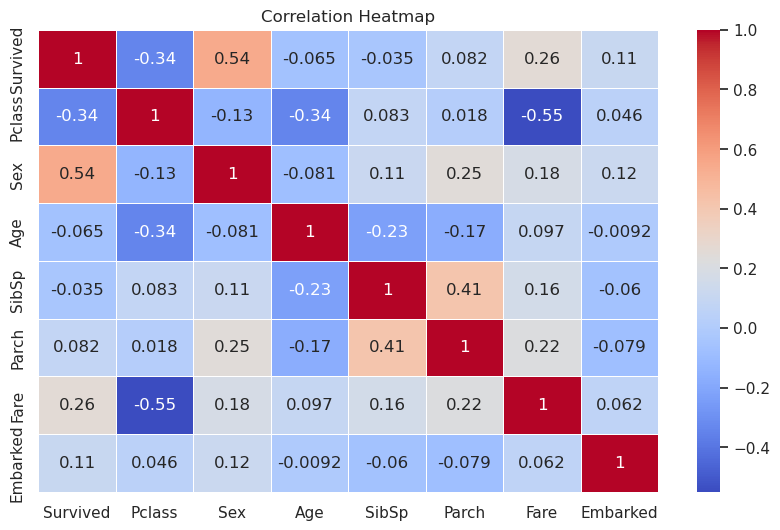

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("titanic.csv")

# Preprocessing
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convert categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Set style
sns.set(style='whitegrid')

# 1. Survival Count
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count')
plt.xticks([0, 1], ['Did not Survive', 'Survived'])
plt.ylabel('Number of Passengers')
plt.show()

# 2. Survival by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Survival by Sex')
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylabel('Count')
plt.show()

# 3. Age Distribution by Survival
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step', stat='density', common_norm=False)
plt.title('Age Distribution by Survival')
plt.show()

# 4. Survival by Passenger Class
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='pastel')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10, 6))
corr = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [10]:
# Get coefficients and intercept
weights = model.coef_[0]
intercept = model.intercept_[0]

# Define sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Choose a few test samples
X_test_subset = X_test.head(5)

# Calculate z = w1*x1 + w2*x2 + ... + b
z = np.dot(X_test_subset, weights) + intercept

# Apply sigmoid to get probability
manual_probs = sigmoid(z)

# Show manual predictions
print("Manual predicted probabilities:\n", manual_probs)

# Compare with model's built-in probabilities
model_probs = model.predict_proba(X_test_subset)[:, 1]
print("\nScikit-learn predicted probabilities:\n", model_probs)


Manual predicted probabilities:
 [0.95627077 0.83468541 0.28216146 0.92987986 0.27633637]

Scikit-learn predicted probabilities:
 [0.95627077 0.83468541 0.28216146 0.92987986 0.27633637]


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


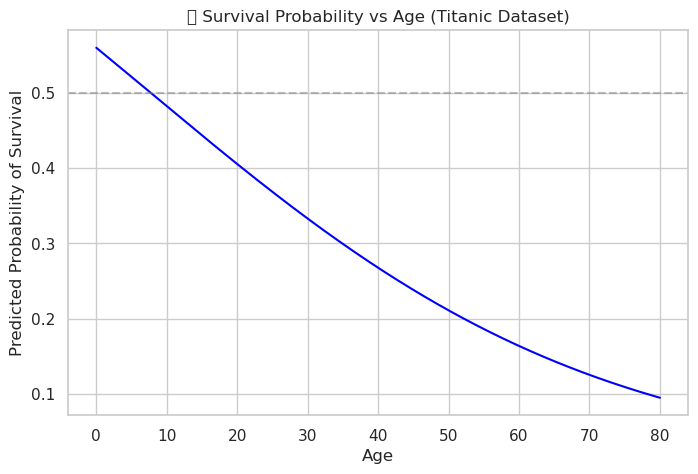

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load and preprocess data
df = pd.read_csv("titanic.csv")

# Basic cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Create a range of ages to simulate predictions
ages = np.linspace(0, 80, 300)
# Use mean values for all other features
avg_input = X_train.mean().to_dict()

# Create input matrix varying age only
X_age = pd.DataFrame([avg_input] * len(ages))
X_age['Age'] = ages

# Compute linear combination z and apply sigmoid
z = np.dot(X_age, model.coef_[0]) + model.intercept_[0]
sigmoid = lambda z: 1 / (1 + np.exp(-z))
probabilities = sigmoid(z)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ages, probabilities, color='blue')
plt.title("📈 Survival Probability vs Age (Titanic Dataset)")
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.grid(True)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.show()
